## Instalar librerías necesarias

In [1]:
# Documentación Ultralytics: https://docs.ultralytics.com/
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00


## Descomprimir archivo con conjunto de datos

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Htv38hPmeikMVqwo0y96")
project = rf.workspace("joaquin-andres-maureira-veliz").project("minecraft-mobs-animal")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to minecraft-mobs-animal-3 in yolov8:: 100%|██████████| 3211/3211 [00:00<00:00, 7234.15it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Librerías a utilizar

In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv
import torch
import os

### Rutas conjunto de datos (train - test)

In [4]:
train_dir = "/content/minecraft-mobs-animal-2/train"
test_dir = "/content/minecraft-mobs-animal-2/test"

## Entrenar modelo

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponible. Usando:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU disponible. Usando CPU.")

GPU disponible. Usando: Tesla T4


In [6]:
# Cargar un modelo YOLO11n preentrenado
model = YOLO('yolov8n-seg.pt')

In [7]:
model.info()

YOLOv8n-seg summary: 151 layers, 3,409,968 parameters, 0 gradients, 12.1 GFLOPs


(151, 3409968, 0, 12.1435648)

In [11]:
train_results = model.train(
    data="/content/minecraft-mobs-animal-3/data.yaml",   # Ruta al archivo de configuración del conjunto de datos
    epochs=150,          # Número de épocas de entrenamiento
    imgsz=640,          # Tamaño de las imágenes durante el entrenamiento
    device=0,       # Usar GPU si está disponible
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/minecraft-mobs-animal-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=

## Evaluar métricas

- **Box (Precision):** Mide la precisión de las cajas delimitadoras detectadas.
- **Recall:** Mide la capacidad del modelo para encontrar todas las intancias de un objeto. Un valor alto indica que el modelo es bueno para encontrar la mayoría de los objetos presentes.
- **mAP50:** Calcula la precisión promedio para cada clase con un umbral de IoU de 0.50 y luego los promedia. Un mAP50 alto indica un buen rendimiento general del modelo.
- **mAP50-95:** Es una métrica más estricta que mAP50. Un mAP50-95 alto indica un rendimiento robusto del modelo en la detección de objetos.

In [12]:
# Cargar el mejor modelo
model = YOLO("/content/runs/segment/train-3/weights/best.pt")

# Evaluar el modelo
metrics = model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,039 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1350.0±383.3 MB/s, size: 34.8 KB)
val: Scanning /content/minecraft-mobs-animal-3/valid/labels.cache... 321 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 321/321 96.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 1.5s/it 30.7s
                   all        321        475      0.889      0.806      0.852       0.68      0.885        0.8       0.84      0.586
                 Cerdo         67        109      0.817      0.872      0.842      0.661      0.822      0.872      0.839      0.599
               Gallina         67         70      0.963      0.957      0.967      0.817      0.951      0.943      0.942      0.613
                  Lobo     

## Visualizar algunas validaciones

- **Ground Truth (Etiqueta Real):** Son las cajas delimitadoras y las etiquetas de clase que indican dónde y qué objetos deberían haber sido detectados.
- **True Positives (Verdaderos Positivos):** Son las predicciones del modelo que coinciden correctamente con una etiqueta real.
- **False Positives (Falsos Positivos):** Son las predicciones del modelo que no coinciden con ninguna etiqueta real. Esto puede ocurrir de dos maneras:
  1. El modelo detectó algo que no es un objeto.
  2. El modelo detectó un objeto real, pero la caja delimitadora predicha no se supoerpone lo suficiente con la caja real (IoU bajo).
- **False Negativos (Falsos Negativos):** Son las etiquetas reales que el modelo no pudo detectar.

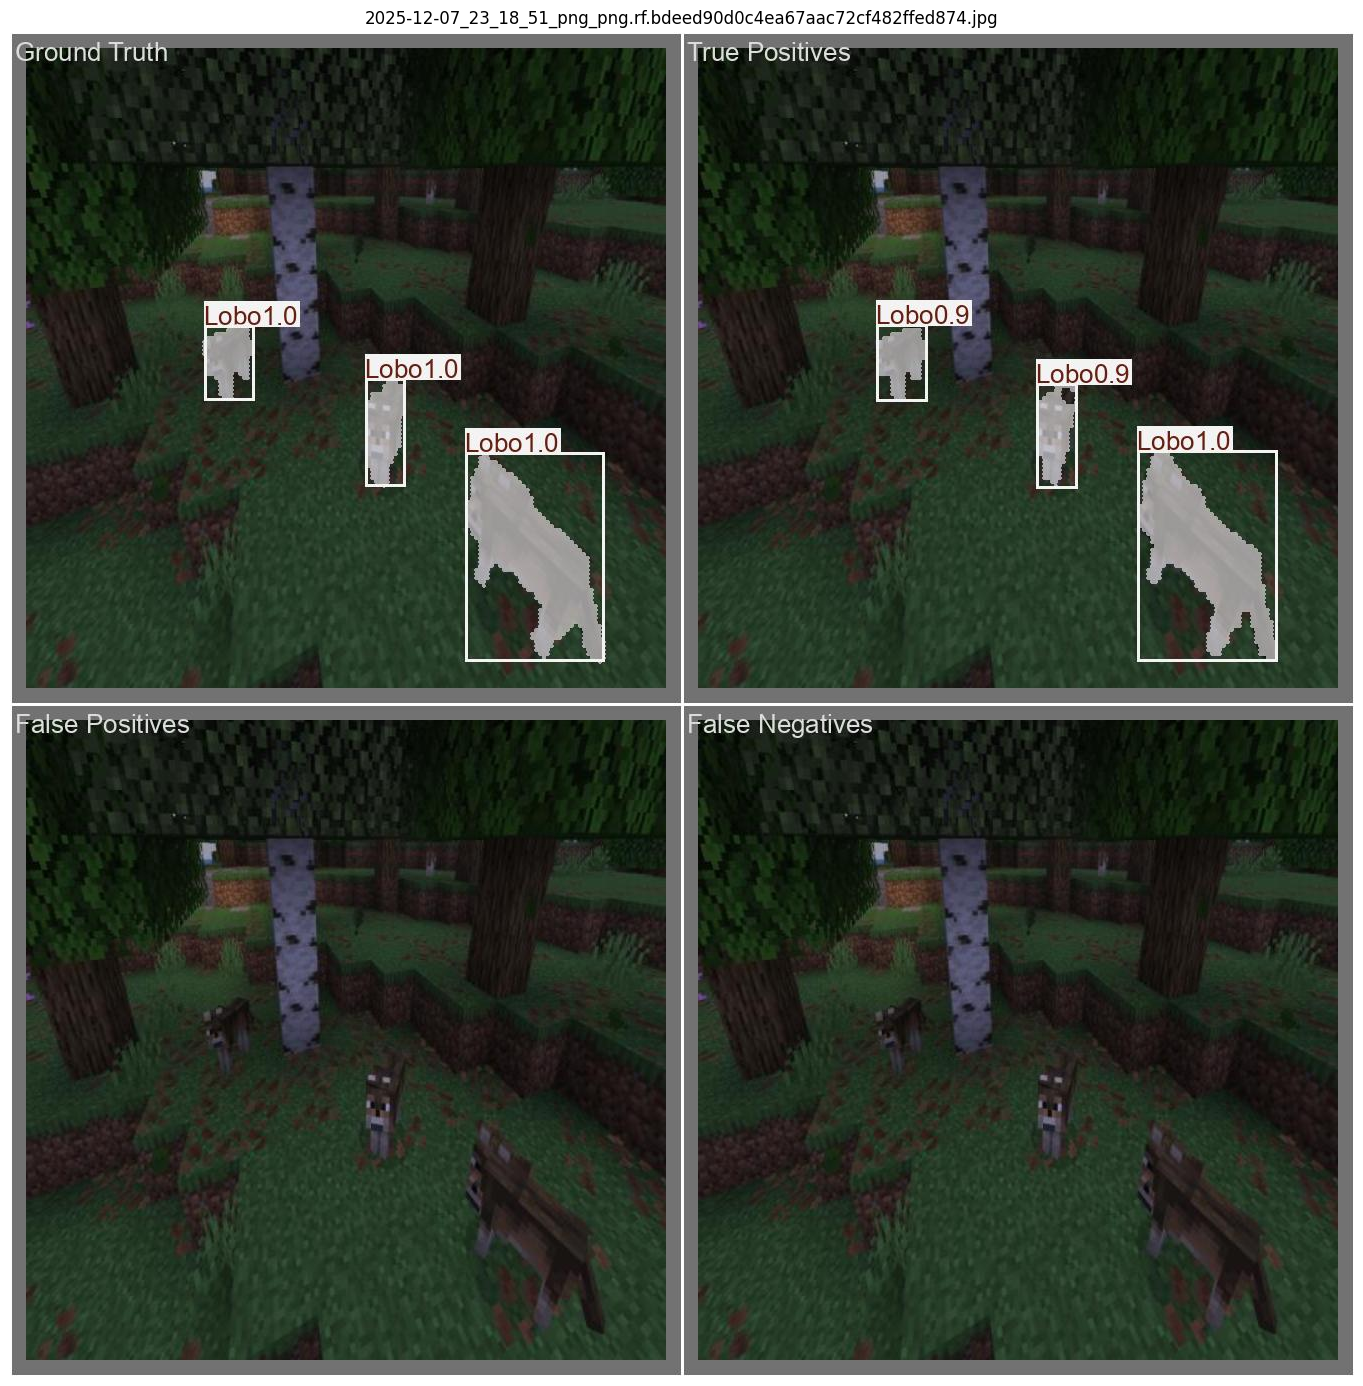

In [18]:
# Ruta de la imagen específica que quieres mostrar
img_path = '/content/runs/segment/val/visualizations/2025-12-07_23_18_51_png_png.rf.bdeed90d0c4ea67aac72cf482ffed874.jpg'

# Verificar si el archivo de imagen existe
if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    # Mostrar la imagen sin bordes blancos
    fig, ax = plt.subplots(figsize=(img.shape[1]/100, img.shape[0]/100), dpi=100) # Ajustar tamaño de figura
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path)) # Usar el nombre del archivo como título
    ax.axis('off') # Ocultar ejes

    # Eliminar el espacio en blanco alrededor de la imagen
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.margins(0,0)
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {img_path}")

## Evaluación gráfico F1-Score/Confidence

El F1-Score es una métrica que combina la **Precisión** y el **Recall**:

$$ \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

Es útil porque proporciona el equilibrio que hay entre la precisión y el recall. Un valor alto de F1-Score indica que el modelo tiene tanto buena precisión (pocas falsas detecciones) como un buen recall (encuentra la mayoría de los objetos).

Es especialmente útil cuando hay un desequilibrio entre las clases o cuando tanto los faltos positivos como los falsos negativos son importantes.

### Interpretación del gráfico

- El eje X:
  - Representa el umbral de confianza que determina cuán seguro debe estar el modelo de que ha encontrado un objeto para considerarlo una detección positiva.
  - Un umbral alto resulta en menos detecciones (menor recall) pero con mayor probabilidad de que sean correctas (mayor precisión).
  - Un umbral bajo resulta en más detecciones (mayor recall) pero también más faltos positivos (menor precisión).
- Para interpretar el gráfico de forma correcta:
  - Busca el punto más alto en la curva. Este punto indica el umbral de confianza óptimo para obtener el F1-Score más alto para tu modelo en este conjunto de datos de validación.
  - La forma de la curva te dice cómo el F1-Score responde a los cambios en el umbral de confianza.

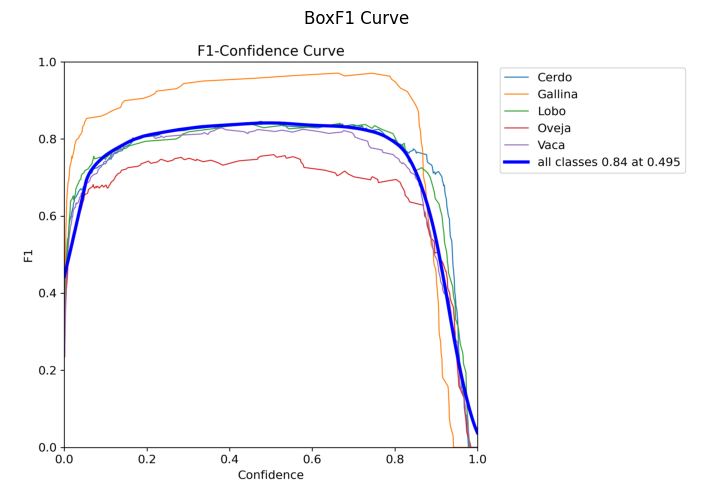

In [19]:
image_path = '/content/runs/segment/val/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Precision/Recall

El gráfico de Precision/Recall muestra la relación entre la precisión y el recall del modelo a diferentes umbrales de confianza.

- **Eje X (Recall):** Representa la proporción de verdaderos positivos que el modelo detectó de todas las instancias reales de un objeto en el conjunto de datos de validación. Un recall alto significa que el modelo encuentra la mayoría de los objetos.

- **Eje Y (Precision):** Representa la proporción de verdaderos positivos entre todas las detecciones positivas realizadas por el modelo. Una precisión alta significa que cuando el modelo detecta algo, es muy probable que sea correcto.

### Interpretación del gráfico

- Una curva más cercana a la esquina superior derecha indica un mejor rendimiento general del modelo, con alta precisión y alto recall simultáneamente.
- El gráfico muestra cómo cambia la precisión a medida que aumenta el recall (disminuyendo el umbral de confianza).

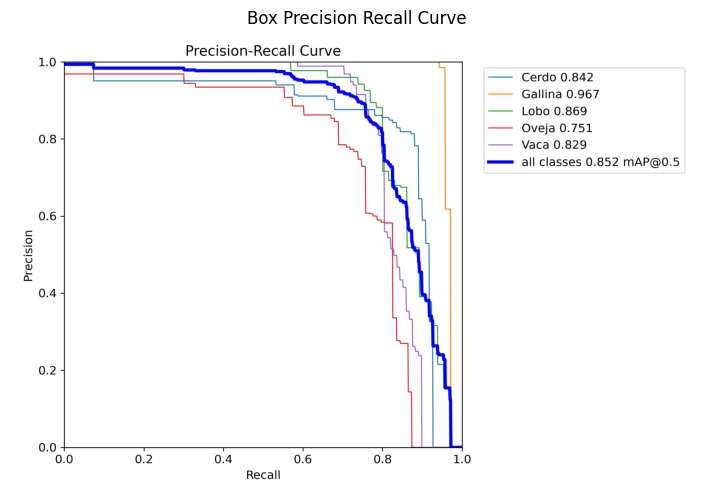

In [20]:
image_path = '/content/runs/segment/val/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Precision/Confidence

Este gráfico muestra cómo la precisión del modelo cambia en función del umbral de confianza utilizado para las detecciones.

- **Eje X (Umbral de Confianza):** Representa el valor mínimo de confianza que una detección debe tener para ser considerada válida.
- **Eje Y (Precisión):** Representa la proporción de detecciones positivas que son verdaderamente correctas para un umbral de confianza dado.

### Interpretación del gráfico

- A medida que el umbral de confianza aumenta, la precisión generalmente también aumenta. Esto se debe a que, al requerir una mayor confianza, se reducen los falsos positivos.
- La curva te permite ver qué precisión puedes esperar a diferentes niveles de confianza. Esto es útil para ajustar el modelo a tus necesidades específicas, dependiendo de si prefieres un modelo con alta precisión (menos falsos positivos) o un modelo que detecte más objetos (potencialmente con más falsos positivos).
- Puedes elegir un umbral de confianza que equilibre la precisión y el recall según los requisitos de tu aplicación.

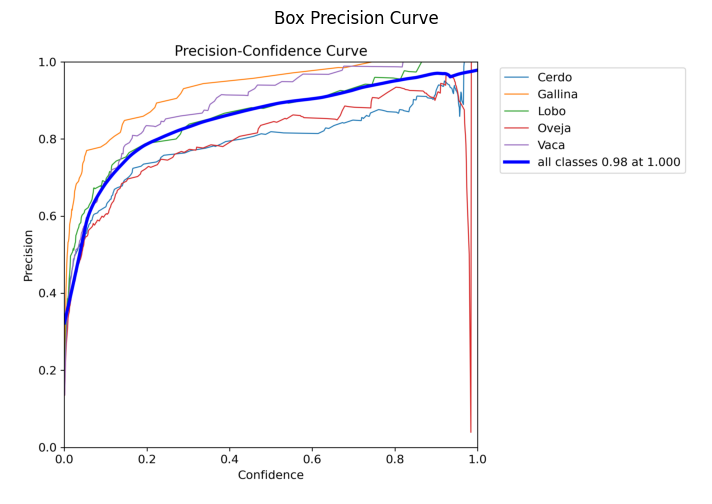

In [21]:
image_path = '/content/runs/segment/val/BoxP_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Precision Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Evaluación gráfico Recall/Confidence

Este gráfico ilustra cómo varía el recall del modelo en función del umbral de confianza aplicado a las detecciones.

- **Eje X (Umbral de Confianza):** Indica el nivel mínimo de confianza requerido para que una detección sea considerada positiva.
- **Eje Y (Recall):** Muestra la proporción de objetos reales que el modelo es capaz de detectar a un umbral de confianza específico.

### Interpretación del gráfico

- A medida que el umbral de confianza disminuye, el recall generalmente aumenta. Esto se debe a que, al ser menos estricto con la confianza, el modelo realiza más detecciones, incluyendo aquellas con menor probabilidad, lo que incrementa la posibilidad de encontrar más objetos reales.
- La curva te permite visualizar el trade-off entre la cantidad de objetos detectados (recall) y la confianza de esas detecciones.
- Puedes utilizar este gráfico para seleccionar un umbral de confianza que te proporcione el nivel de recall deseado para tu aplicación, incluso si esto significa aceptar un mayor número de falsos positivos (lo cual se puede ver en el gráfico de Precision/Confidence).

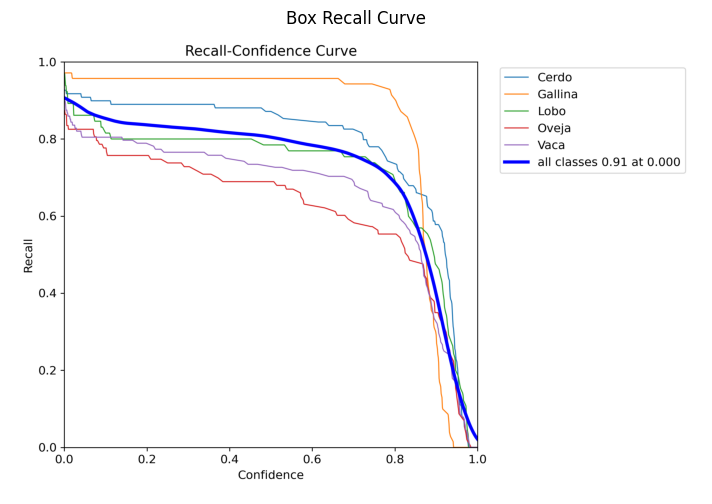

In [22]:
image_path = '/content/runs/segment/val/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Matriz de Confusión

### Interpretación de la Matriz de Confusión

- **Diagonal Principal (de arriba a la izquierda a abajo a la derecha):** Muestra el número de predicciones correctas para cada clase. Cuanto más altos sean estos valores, mejor será el rendimiento del modelo.
- **Fuera de la Diagonal Principal:** Muestra el número de errores de clasificación, es decir, cuándo el modelo predijo incorrectamente una clase.
  - Por ejemplo, un valor en la fila de "player" y la columna de "referee" indica cuántas veces el modelo predijo "referee" cuando en realidad era un "player".

### Componentes Clave

- **Verdaderos Positivos (TP):** El modelo predijo correctamente la clase positiva.
- **Verdaderos Negativos (TN):** El modelo predijo correctamente la clase negativa.
- **Falsos Positivos (FP):** El modelo predijo la clase positiva incorrectamente (error de Tipo I).
- **Falsos Negativos (FN):** El modelo predijo la clase negativa incorrectamente (error de Tipo II).

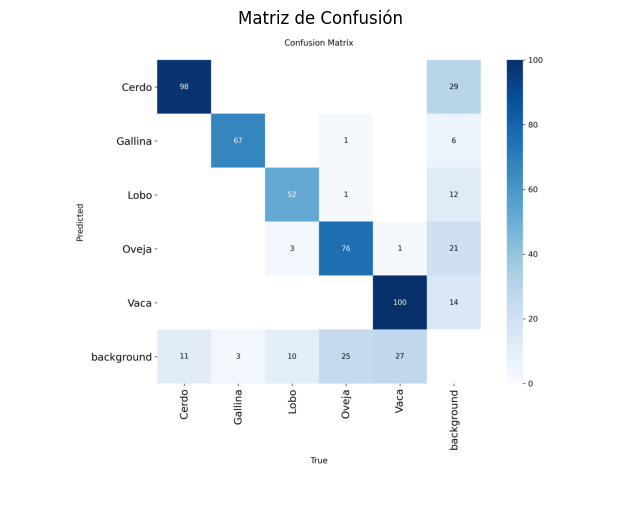

In [23]:
image_path = '/content/runs/segment/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Matriz de Confusión Normalizada

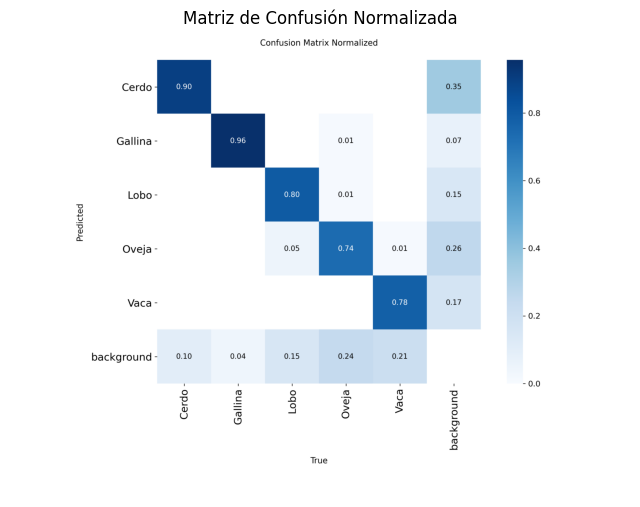

In [24]:
image_path = '/content/runs/segment/val/confusion_matrix_normalized.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión Normalizada')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

## Predicciones del modelo

In [34]:
# Cargar modelo YOLO entrenado
model = YOLO('/content/runs/segment/train-3/weights/best.pt')

video_path = '/content/a.mp4'
output_path = '/content/resultado.mp4'

colors = {
    0: (0, 255, 0),
    1: (255, 0, 0),
    2: (0, 0, 255),
    3: (255, 255, 0),
    4: (0, 255, 255),
}

cap = cv.VideoCapture(video_path)

if not cap.isOpened():
    print("No se pudo abrir el video")
else:
    fps = cap.get(cv.CAP_PROP_FPS)
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    out = cv.VideoWriter(output_path, fourcc, fps, (width, height))

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False)

        final_image = frame.copy()
        overlay = frame.copy()

        for result in results:
            if result.masks is None:
                continue

            for mask_coords, box in zip(result.masks.xy, result.boxes):
                x1, y1, x2, y2 = box.xyxy[0]
                class_id = int(box.cls[0])
                label = model.names[class_id]
                conf = float(box.conf[0])
                points = np.int32([mask_coords])
                color = colors.get(class_id, (255, 255, 255))

                cv.fillPoly(overlay, points, color)
                cv.rectangle(final_image, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

                text = f'{label}: {conf:.2f}'
                (w, h), _ = cv.getTextSize(text, cv.FONT_HERSHEY_SIMPLEX, 0.6, 1)
                cv.rectangle(final_image, (int(x1), int(y1) - 20), (int(x1) + w, int(y1)), color, -1)
                cv.putText(final_image, text, (int(x1), int(y1) - 5), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        alpha = 0.5
        cv.addWeighted(overlay, alpha, final_image, 1 - alpha, 0, final_image)

        out.write(final_image)

    cap.release()
    out.release()
    print(f"Video guardado en: {output_path}")


Video guardado en: /content/resultado.mp4


## Análisis Crítico de las Predicciones

Se evaluó el modelo sobre un video nuevo de gameplay de Minecraft, no perteneciente al dataset de entrenamiento, con escenarios desafiantes: mobs en movimiento, oclusión parcial, desenfoque, mobs no entrenados en pantalla, y eventos dinámicos como la muerte de un animal.

**Aciertos:**
- El modelo detecta correctamente un Lobo de pie, con buena iluminación y confianza aceptable (0.73–0.86).
- En una escena de interacción (lobo atacando a una oveja), el modelo detecta y segmenta ambos animales simultáneamente pese a la oclusión parcial entre ellos, demostrando robustez ante superposición de instancias.
- Mantiene la detección de una oveja incluso con desenfoque de movimiento y a distancia (confianza 0.77).

**Fallos y limitaciones:**
- Se detectó un **falso negativo**: una oveja de lana negra, completamente visible, no fue detectada en absoluto. Esto sugiere que el modelo asocia la clase "Oveja" principalmente al color de lana blanco predominante en el dataset, y no generaliza bien a variaciones de color de la misma clase.
- Se identificó un **falso positivo curioso**: en el instante en que una oveja muere, Minecraft aplica un efecto visual de daño que tiñe momentáneamente al mob (destello rosado). El modelo clasificó ese frame como **"Cerdo" (0.95)** en lugar de "Oveja", probablemente porque el tono de piel resultante se parece más al color rosado característico de los cerdos en el dataset de entrenamiento que al de una oveja normal. Esto evidencia que el modelo depende fuertemente del color como característica discriminante, y es sensible a alteraciones visuales momentáneas (efectos de daño, iluminación, partículas).
- Se detectó otro **falso positivo**: al soltar el ítem de lana (bloque de lana) tras esquilar o matar a la oveja, el modelo lo clasificó como **"Oveja" (0.78)**, confundiendo un objeto inanimado (bloque de lana en el suelo) con el animal completo. Esto ocurre porque la textura y el color del bloque de lana son visualmente casi idénticos a la lana de la oveja, y el modelo no distingue la forma/anatomía completa del animal de un simple bloque de su mismo material.
- Mobs parcialmente visibles en el borde de la pantalla no fueron detectados, indicando que el modelo requiere una porción suficiente del objeto dentro del cuadro para reconocerlo.

**Conclusión:** el pipeline funciona bien en condiciones estándar y con oclusión parcial, pero muestra una dependencia notoria del color/textura por sobre la forma o el contexto del objeto. Esto se traduce en errores concretos: confunde animales con ítems del mismo material (bloques de lana → "Oveja"), confunde una clase con otra cuando el color cambia momentáneamente (oveja herida → "Cerdo"), y falla al generalizar a variaciones de color dentro de la misma clase (oveja negra no detectada). Estas limitaciones apuntan a que el dataset de entrenamiento podría beneficiarse de mayor diversidad de color/textura por clase y de ejemplos negativos (ítems sueltos que no son el animal).